IEX REALTIME MARKET ANALYSIS
Market Clearing Volume. Hourly Average Market Clearing Volume (MCV) over a 24-hour period during FY 2022 to 2025 june



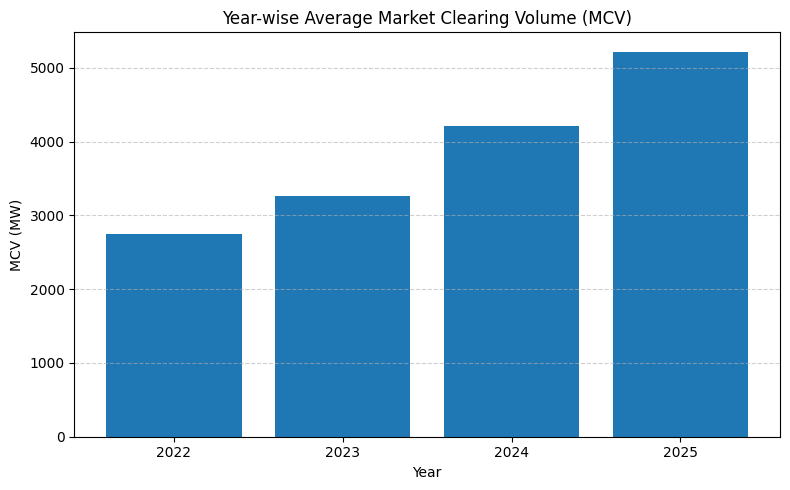

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your Excel file
df = pd.read_excel(r"C:\Users\nanda\Downloads\RTM_Market Snapshot april2022-june2025.xlsx")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Calculate year-wise average MCV
yearly_avg_mcv = df.groupby('Year')['MCV (MW)'].mean().reset_index()

# Plot year-wise average MCV
plt.figure(figsize=(8, 5))
plt.bar(yearly_avg_mcv['Year'], yearly_avg_mcv['MCV (MW)'])
plt.title("Year-wise Average Market Clearing Volume (MCV)")
plt.xlabel("Year")
plt.ylabel("MCV (MW)")
plt.xticks(yearly_avg_mcv['Year'])  # show only available years
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



*Year-wise Average MCV*
1.   MCV has shown a steady year-on-year growth from ~2800 MW in 2022 to above 5200 MW in 2025.
2.   This trend reflects rising market participation, demand growth, or better grid integration over the years.

*Month-wise Average MCV*
1.  Highest MCVs occur in May and June (~4400+ MW), likely due to peak summer demand (cooling load).
2.  MCV declines in November and December, indicating lower energy demand during mild weather.





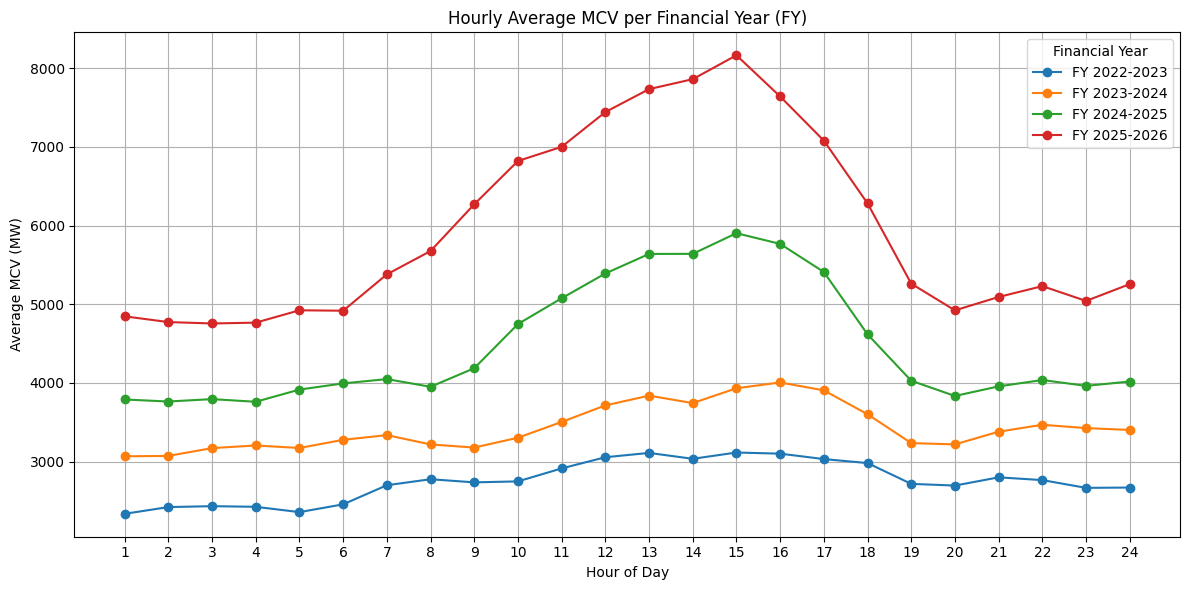

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("/content/RTM_Market Snapshot april2022-june2025.xlsx")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Hour'] = df['Hour'].astype(int)

# Create FY (Financial Year) label
def get_fy(date):
    return f"FY {date.year}-{date.year+1}" if date.month >= 4 else f"FY {date.year-1}-{date.year}"

df['FY'] = df['Date'].apply(get_fy)

# Group by FY and Hour -> average MCV for each hour of day in that FY
fy_hourly_avg = df.groupby(['FY', 'Hour'])['MCV (MW)'].mean().reset_index()

# Plot: One curve per FY
plt.figure(figsize=(12, 6))

for fy in fy_hourly_avg['FY'].unique():
    fy_data = fy_hourly_avg[fy_hourly_avg['FY'] == fy]
    plt.plot(fy_data['Hour'], fy_data['MCV (MW)'], label=fy, marker='o')

plt.title("Hourly Average MCV per Financial Year (FY)")
plt.xlabel("Hour of Day")
plt.ylabel("Average MCV (MW)")
plt.xticks(range(1, 25))
plt.grid(True)
plt.legend(title="Financial Year")
plt.tight_layout()
plt.show()


*Hourly Average MCV per Financial Year (FY 2022 – Jun 2025)*
1.   Each successive year shows a notable increase in MCV across all hours.
2.   FY 2025–2026 reaches a peak of 8200+ MW at 3 PM, significantly higher than previous years.
3.   The peak-demand window (10 AM–5 PM) is consistently the most active period, and its intensity is rising year over year.
4.   Evening and night-time volumes remain relatively stable, with slight increases in recent years.

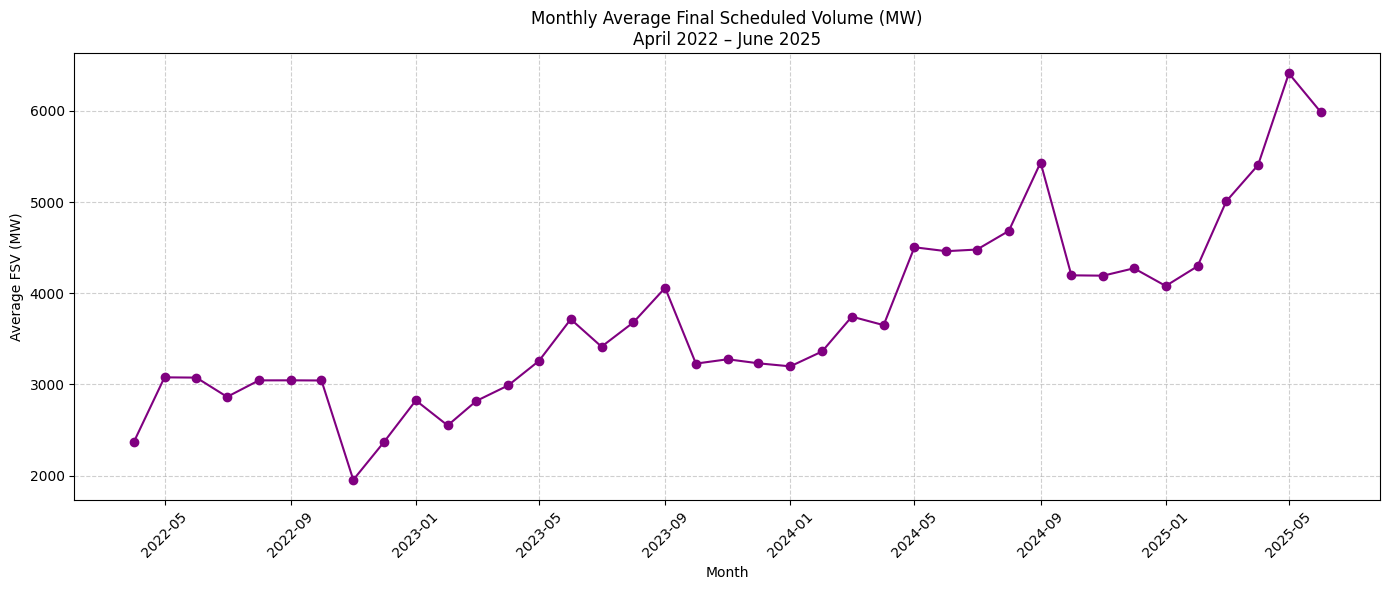

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "/content/RTM_Market Snapshot april2022-june2025.xlsx"  # Replace if needed
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Filter data from April 2022 to June 2025
df_filtered = df[(df['Date'] >= '2022-04-01') & (df['Date'] <= '2025-06-30')]

# Extract Year-Month
df_filtered['Month'] = df_filtered['Date'].dt.to_period('M')

# Calculate Monthly Average FSV
monthly_avg_fsv = df_filtered.groupby('Month')['Final Scheduled Volume (MW)'].mean().reset_index()
monthly_avg_fsv['Month'] = monthly_avg_fsv['Month'].dt.to_timestamp()

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(monthly_avg_fsv['Month'], monthly_avg_fsv['Final Scheduled Volume (MW)'],
         marker='o', linestyle='-', color='purple')
plt.title('Monthly Average Final Scheduled Volume (MW)\nApril 2022 – June 2025')
plt.xlabel('Month')
plt.ylabel('Average FSV (MW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Monthly Average Final Scheduled Volume (MW)*
*  Overall Growth: There is a steady upward trend in final scheduled volume over time.
*  Sharp Rise: Noticeable increase after mid-2023, peaking in May 2025.
*  Seasonal Dips: Few minor drops observed (e.g., around Dec 2022 and Aug 2023).
*  Conclusion: Indicates increasing energy demand or market participation over the period.

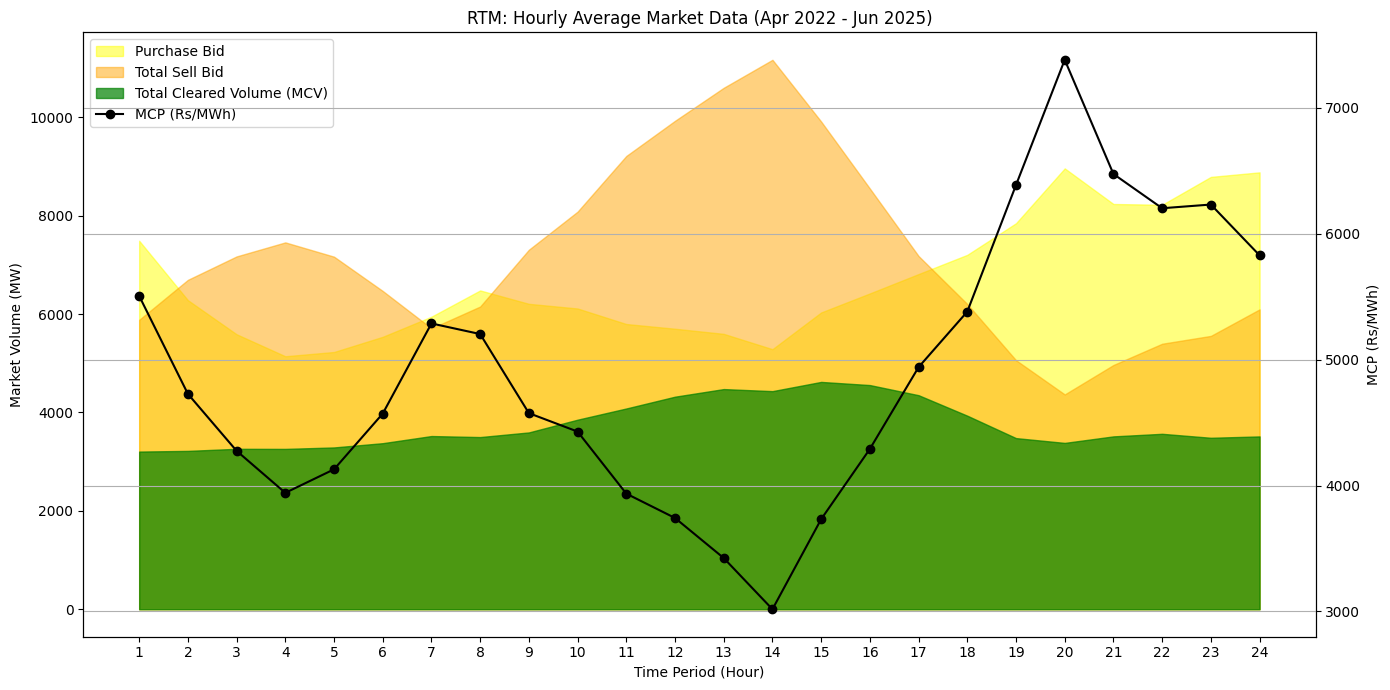

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (already cleaned earlier in the session)
file_path = "/content/RTM_Market Snapshot april2022-june2025.xlsx"
df = pd.read_excel(file_path)

# Combine 'Date' and 'Hour' to create a datetime object and extract hour
# The 'Date' column is already in datetime format from previous operations.
# Let's ensure 'Hour' is integer for combination.
df['Hour'] = df['Hour'].astype(int)
# Create a dummy time part for combining with Date, assuming 'Hour' is start of the hour
# Or, we can directly use the 'Hour' column as the x-axis for hourly plots
# Let's use the 'Hour' column directly as the x-axis as done in previous plots.

# Filter relevant columns and group by Hour
hourly_avg = df.groupby('Hour').agg({
    'Purchase Bid (MW)': 'mean',
    'Sell Bid (MW)': 'mean',
    'MCV (MW)': 'mean', # Corrected column name from 'Total Cleared Volume (MW)' to 'MCV (MW)'
    'MCP (Rs/MWh) *': 'mean' # Corrected column name from 'Market Clearing Price (Rs/MWh)' to 'MCP (Rs/MWh) *'
}).reset_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 7))

# Fill plots for MW metrics
ax1.fill_between(hourly_avg['Hour'], hourly_avg['Purchase Bid (MW)'], color='yellow', alpha=0.5, label='Purchase Bid')
ax1.fill_between(hourly_avg['Hour'], hourly_avg['Sell Bid (MW)'], color='orange', alpha=0.5, label='Total Sell Bid')
ax1.fill_between(hourly_avg['Hour'], hourly_avg['MCV (MW)'], color='green', alpha=0.7, label='Total Cleared Volume (MCV)')

ax1.set_xlabel('Time Period (Hour)')
ax1.set_ylabel('Market Volume (MW)')
ax1.set_title('RTM: Hourly Average Market Data (Apr 2022 - Jun 2025)')
ax1.set_xticks(range(1, 25)) # Set x-ticks to show all hours from 1 to 24


# MCP on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(hourly_avg['Hour'], hourly_avg['MCP (Rs/MWh) *'], color='black', marker='o', label='MCP (Rs/MWh)') # Corrected column name
ax2.set_ylabel('MCP (Rs/MWh)')

# Legends
lines_labels = ax1.get_legend_handles_labels()
lines_labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines_labels[0] + lines_labels2[0], lines_labels[1] + lines_labels2[1], loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()

*RTM: Hourly Average Market Data (Apr 2022 - Jun 2025)*

1. Demand vs Supply Pattern:
*  Purchase bids rise sharply after 18:00 hrs, peaking between 19:00–22:00 hrs, indicating evening peak demand.
*  Sell bids peak between 11:00–14:00 hrs, likely due to solar power injection and generator availability.

2. Market Cleared Volume (MCV):
*  Remains relatively stable (≈ 3000–4500 MW) throughout the day.
*  Slightly higher between 10:00–16:00 hrs, aligning with generator availability.

3. MCP (Market Clearing Price):
*  Lowest at 14:00 hrs (~₹3000/MWh) due to maximum sell-side availability.
*  Peaks at 20:00 hrs (~₹7400/MWh) due to high demand and limited supply, a classic evening peak price surge.

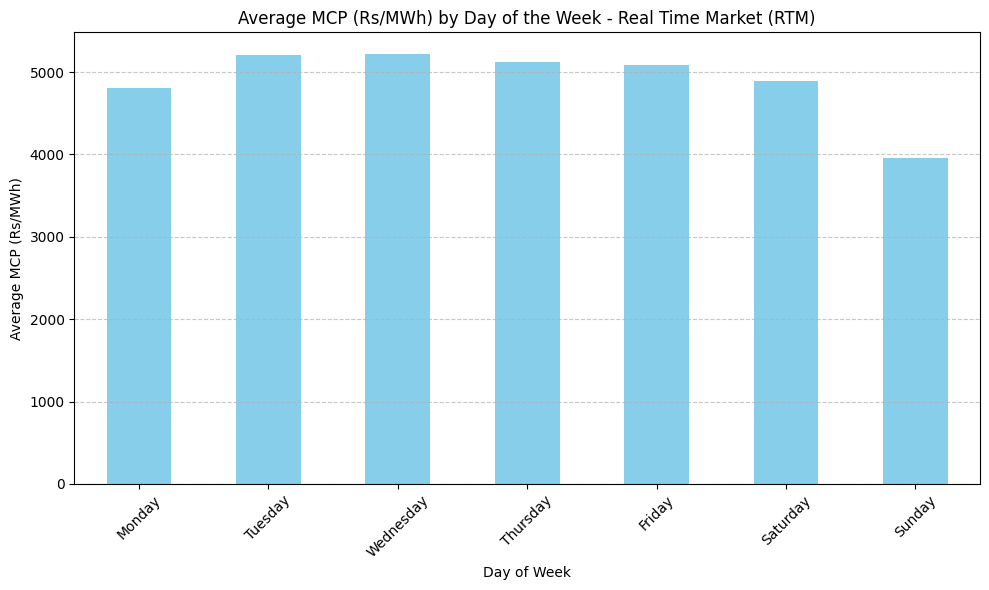

In [ ]:
 import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the previously uploaded Excel file
file_path = "/content/RTM_Market Snapshot april2022-june2025.xlsx"
df = pd.read_excel(file_path)

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Combine 'Date' and 'Hour' to create a full datetime object
# We assume the hour is the start of that hour period
df['Datetime'] = df.apply(lambda row: row['Date'] + pd.Timedelta(hours=row['Hour'] - 1), axis=1)

# Extract the day of the week from the new 'Datetime' column
df['DayOfWeek'] = df['Datetime'].dt.day_name()

# Group by day of the week and calculate average MCP
avg_mcp_by_day_rtm = df.groupby('DayOfWeek')['MCP (Rs/MWh) *'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plotting
plt.figure(figsize=(10, 6))
avg_mcp_by_day_rtm.plot(kind='bar', color='skyblue')
plt.title('Average MCP (Rs/MWh) by Day of the Week - Real Time Market (RTM)')
plt.ylabel('Average MCP (Rs/MWh)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Average MCP (Rs/MWh) by Day of the Week\nApril 2022 – June 2025*

1.   Tuesday and Wednesday exhibit the highest average MCP, both crossing ₹5200/MWh.
2.   Monday and Saturday have similar average prices, around ₹4800–₹4900/MWh.
3.   Sunday records the lowest MCP, approximately ₹4000/MWh, likely due to reduced demand.
4.   Weekdays (Mon–Fri) show consistently high MCP, indicating strong weekday demand in the real-time market.



NameError: name 'mdates' is not defined

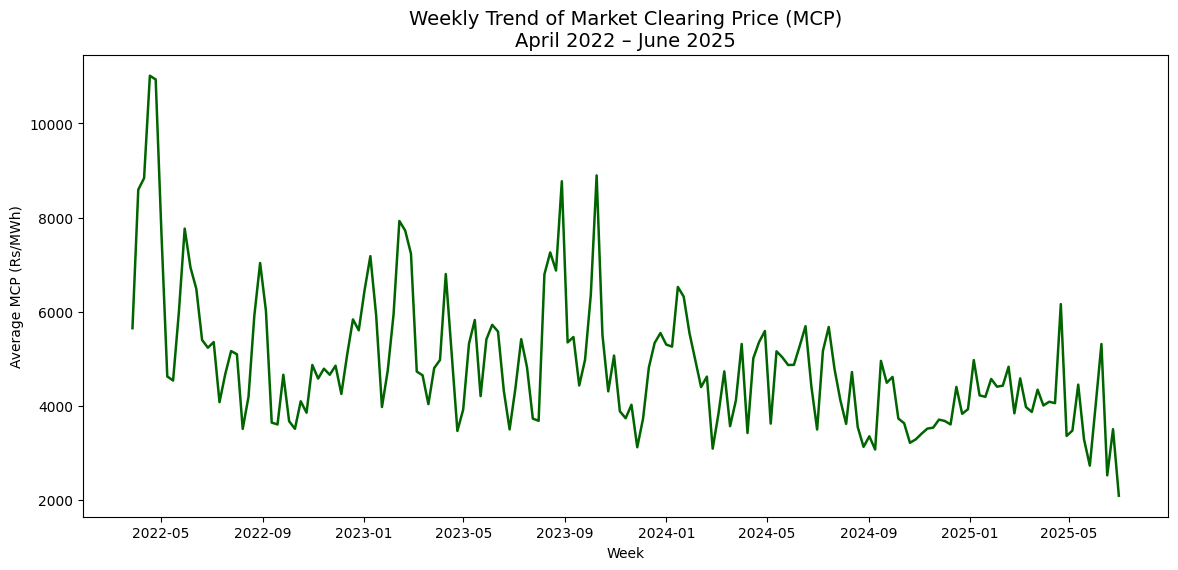

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "/content/RTM_Market Snapshot april2022-june2025.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Filter data in date range
df_filtered = df[(df['Date'] >= '2022-04-01') & (df['Date'] <= '2025-06-30')]

# Create a 'Week' column (start of each week)
df_filtered['Week'] = df_filtered['Date'] - pd.to_timedelta(df_filtered['Date'].dt.weekday, unit='d')
df_weekly_mcp = df_filtered.groupby('Week')['MCP (Rs/MWh) *'].mean().reset_index()

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(df_weekly_mcp['Week'], df_weekly_mcp['MCP (Rs/MWh) *'], color='darkgreen', linewidth=1.8)

plt.title('Weekly Trend of Market Clearing Price (MCP)\nApril 2022 – June 2025', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Average MCP (Rs/MWh)')

# Format x-axis ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # show every 3rd month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Apr 2022'
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


*Weekly Trend of Market Clearing Price (MCP)\nApril 2022 – June 2025*
1.   Early 2022 spike: MCP surged above ₹10,000/MWh in April–May 2022, possibly due to fuel shortages or high summer demand.
2.   Volatile trend: Throughout 2022–2023, prices fluctuated between ₹3,500–₹8,000/MWh, indicating unstable market dynamics.
3.   Gradual stabilization: Post mid-2023, volatility reduces. Prices mostly range between ₹3,500–₹6,000/MWh.
4.   Recent decline: From late 2024 to June 2025, MCP trends downward, approaching ₹3,000–₹4,000/MWh, showing improved market efficiency or supply-demand balance.



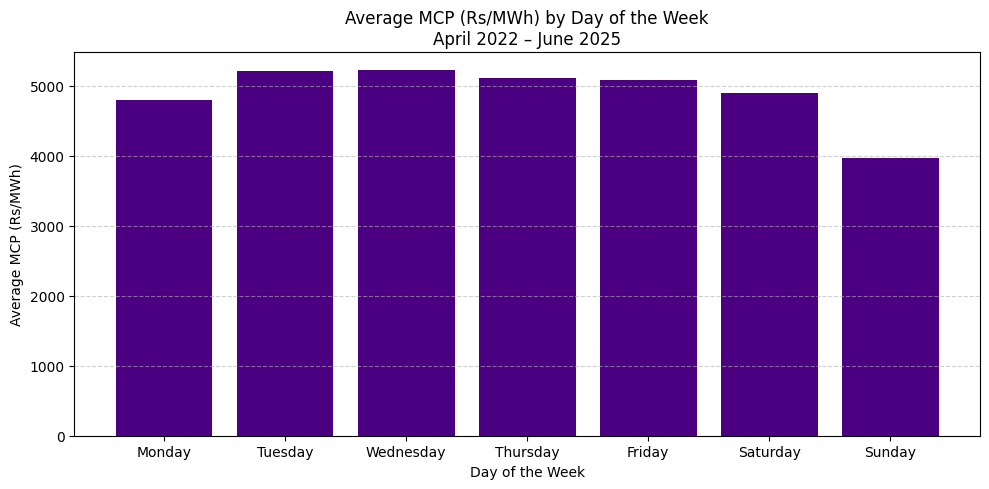

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "/content/RTM_Market Snapshot april2022-june2025.xlsx"  # Update if needed
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Filter data for required date range
df_filtered = df[(df['Date'] >= '2022-04-01') & (df['Date'] <= '2025-06-30')]

# Add day of the week (0=Monday, 6=Sunday)
df_filtered['DayOfWeek'] = df_filtered['Date'].dt.day_name()

# Calculate average MCP by day of the week
avg_mcp_by_day = df_filtered.groupby('DayOfWeek')['MCP (Rs/MWh) *'].mean().reset_index()

# Sort days in order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_mcp_by_day['DayOfWeek'] = pd.Categorical(avg_mcp_by_day['DayOfWeek'], categories=days_order, ordered=True)
avg_mcp_by_day = avg_mcp_by_day.sort_values('DayOfWeek')

# Plotting
plt.figure(figsize=(10, 5))
plt.bar(avg_mcp_by_day['DayOfWeek'], avg_mcp_by_day['MCP (Rs/MWh) *'], color='indigo')
plt.title('Average MCP (Rs/MWh) by Day of the Week\nApril 2022 – June 2025')
plt.xlabel('Day of the Week')
plt.ylabel('Average MCP (Rs/MWh)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

*Average MCP (Rs/MWh) by Day of the Week - Real Time Market (RTM)*

1. Weekday Trend (Mon–Fri):
*  MCP remains consistently high (~₹5000–5200/MWh) on weekdays.
*  Peak on Wednesday & Tuesday, possibly due to industrial/commercial load activity.

2. Weekend Behavior:
*  Saturday sees a mild dip (~₹4900/MWh).
*  Sunday MCP drops significantly to ~₹3900/MWh, reflecting reduced demand from industry and increased availability of renewables (especially solar).

3. RTM prices follow a clear weekday–weekend cycle.

4. Buyers may optimize procurement by shifting flexible loads to Sunday, while sellers should plan peak generation dispatch on Tuesday–Wednesday for higher revenues.

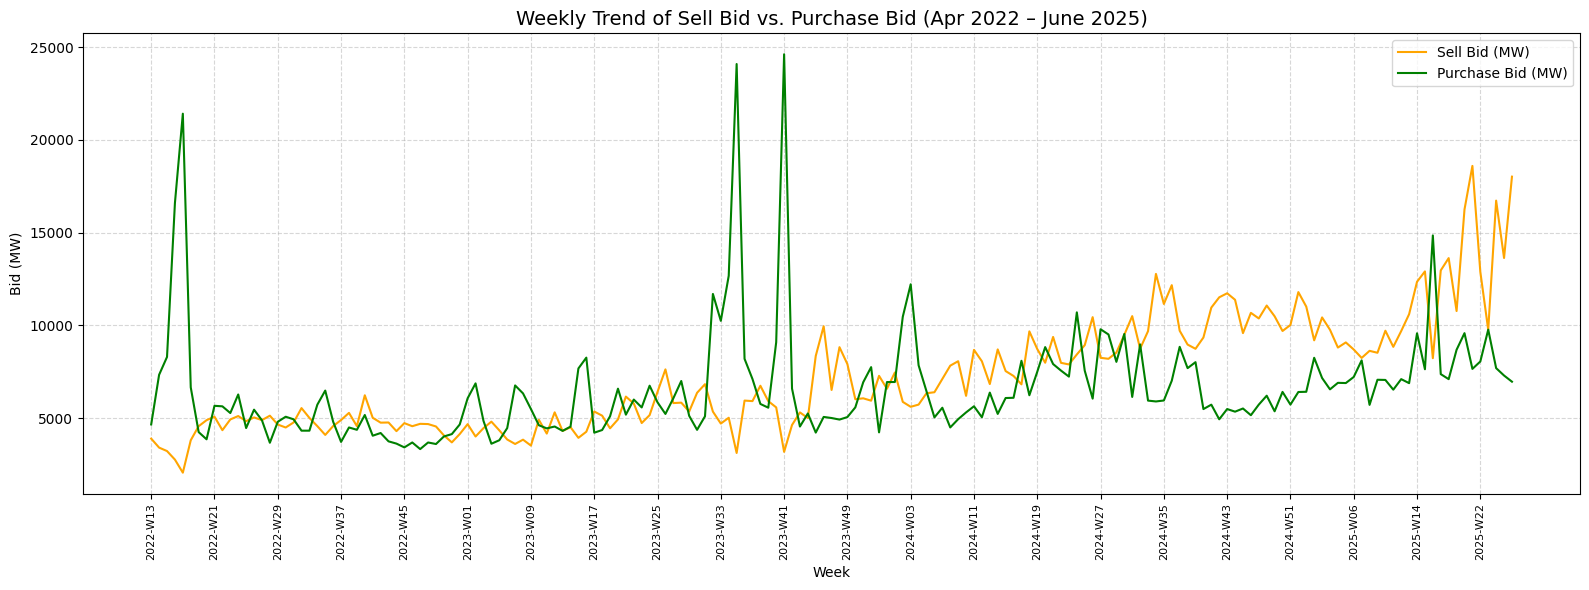

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel("/content/RTM_Market Snapshot april2022-june2025.xlsx")

# Fix the date parsing
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Add Week and FY
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year
df['FY'] = df['Date'].apply(lambda x: f"FY {x.year}-{x.year+1}" if x.month >= 4 else f"FY {x.year-1}-{x.year}")

# Filter only Apr 2022 onward
df_filtered = df[df['Date'] >= '2022-04-01']

# Create Year-Week labels
df_filtered['Year-Week'] = df_filtered['Date'].dt.strftime('%Y-W%U')

# Weekly average
weekly_bid = df_filtered.groupby('Year-Week').agg({
    'Sell Bid (MW)': 'mean',
    'Purchase Bid (MW)': 'mean'
}).reset_index()

# Plotting
plt.figure(figsize=(16,6))
plt.plot(weekly_bid['Year-Week'], weekly_bid['Sell Bid (MW)'], label='Sell Bid (MW)', color='orange')
plt.plot(weekly_bid['Year-Week'], weekly_bid['Purchase Bid (MW)'], label='Purchase Bid (MW)', color='green')

plt.title('Weekly Trend of Sell Bid vs. Purchase Bid (Apr 2022 – June 2025)', fontsize=14)
plt.xlabel('Week')
plt.ylabel('Bid (MW)')

# Reduce clutter in x-axis labels
plt.xticks(ticks=weekly_bid.index[::8], labels=weekly_bid['Year-Week'][::8], rotation=90, fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


*Weekly Trend of Sell Bid vs. Purchase Bid (Apr 2022 – June 2025)*

1.   Sell Bids (orange) show a steady rise, reaching ~20,000 MW by 2025.
2.   Purchase Bids (green) are more volatile, with sharp spikes (~25,000 MW) early on.
3.   Initially, demand (purchase) exceeded supply; later, supply overtook demand.
4.   Indicates increasing generator participation and a possible shift toward oversupply.

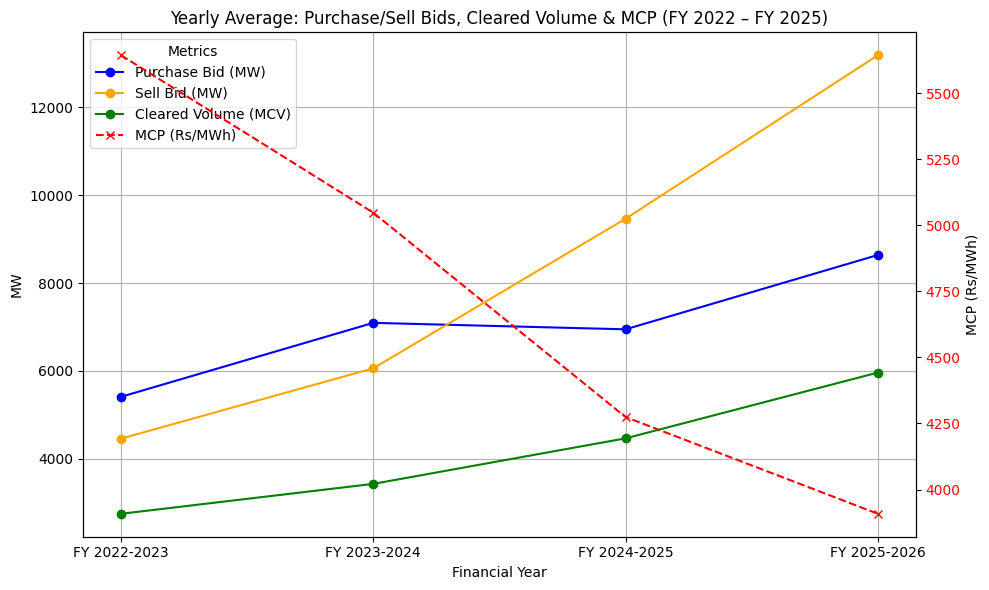

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and preprocess
df = pd.read_excel("/content/RTM_Market Snapshot april2022-june2025.xlsx")
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Define Financial Year (FY) function
def get_fy(date):
    return f"FY {date.year}-{date.year+1}" if date.month >= 4 else f"FY {date.year-1}-{date.year}"

df['FY'] = df['Date'].apply(get_fy)

# Group by FY and calculate average for each metric
fy_avg = df.groupby('FY').agg({
    'Purchase Bid (MW)': 'mean',
    'Sell Bid (MW)': 'mean',
    'MCV (MW)': 'mean',
    'MCP (Rs/MWh) *': 'mean'
}).reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# First Y-axis (MW metrics)
ax1.plot(fy_avg['FY'], fy_avg['Purchase Bid (MW)'], label='Purchase Bid (MW)', color='blue', marker='o')
ax1.plot(fy_avg['FY'], fy_avg['Sell Bid (MW)'], label='Sell Bid (MW)', color='orange', marker='o')
ax1.plot(fy_avg['FY'], fy_avg['MCV (MW)'], label='Cleared Volume (MCV)', color='green', marker='o')
ax1.set_xlabel("Financial Year")
ax1.set_ylabel("MW")
ax1.tick_params(axis='y')
ax1.grid(True)

# Second Y-axis (MCP)
ax2 = ax1.twinx()
ax2.plot(fy_avg['FY'], fy_avg['MCP (Rs/MWh) *'], label='MCP (Rs/MWh)', color='red', linestyle='--', marker='x')
ax2.set_ylabel("MCP (Rs/MWh)")
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', title="Metrics")

# Title
plt.title("Yearly Average: Purchase/Sell Bids, Cleared Volume & MCP (FY 2022 – FY 2025)")
plt.tight_layout()
plt.show()


*Yearly Average: Purchase/Sell Bids, Cleared Volume & MCP (FY 2022 – FY 2025)*

1.   Purchase Bids (Blue) and Sell Bids (Orange) both rise steadily, with Sell Bids growing significantly faster — from ~4500 MW to ~13,000 MW, suggesting more aggressive supply-side participation.
2.   Cleared Volume (Green) also increases year-on-year, crossing 5800 MW in FY 2025–26 — reflecting higher transaction efficiency.
3.   MCP (Red Dotted) shows a clear decline — from ₹5600/MWh to below ₹4000/MWh, indicating improved supply adequacy and market competitiveness.



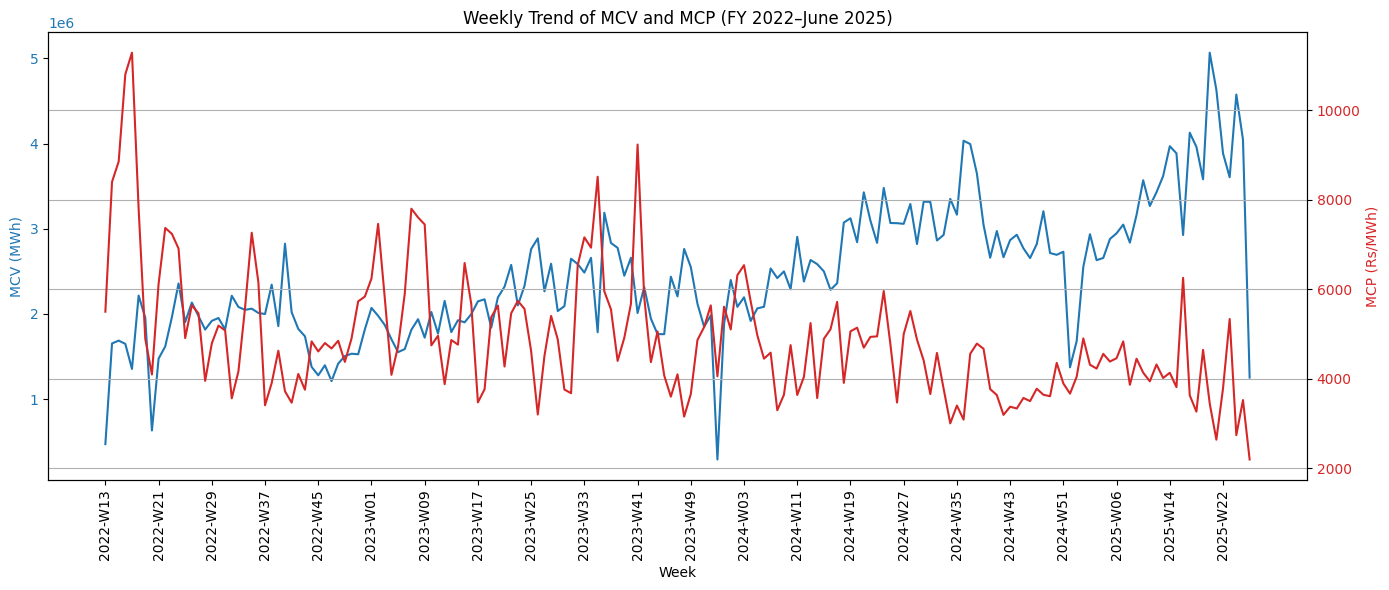

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_excel("/content/RTM_Market Snapshot april2022-june2025.xlsx")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

# Add week number and year
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year
df['Year-Week'] = df['Date'].dt.strftime('%Y-W%U')  # Alternative: '%Y-%V'

# Group by week and calculate average MCP and total MCV
weekly_data = df.groupby('Year-Week').agg({
    'MCP (Rs/MWh) *': 'mean',
    'MCV (MW)': 'sum'
}).reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(14,6))

color = 'tab:blue'
ax1.set_xlabel('Week')
ax1.set_ylabel('MCV (MWh)', color=color)
ax1.plot(weekly_data['Year-Week'], weekly_data['MCV (MW)'], color=color, label='MCV')
ax1.tick_params(axis='y', labelcolor=color)

# Reduce x-ticks (show every 8th week)
ax1.set_xticks(weekly_data['Year-Week'][::8])
plt.xticks(rotation=90)

# Second y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('MCP (Rs/MWh)', color=color)
ax2.plot(weekly_data['Year-Week'], weekly_data['MCP (Rs/MWh) *'], color=color, label='MCP')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Weekly Trend of MCV and MCP (FY 2022–June 2025)')
plt.tight_layout()
plt.grid(True)
plt.show()


*Weekly Trend of MCV and MCP (FY 2022–June 2025)*

1. MCP (Market Clearing Price) – Red Line:


*   Sharp spikes in April–May 2022 (above ₹10,000/MWh), aligning with early summer peak demand or supply constraints.
*   High volatility until mid-2023; stabilizes below ₹6,000/MWh post that.
*   Downward trend visible from late 2024, ending near ₹2,000/MWh by mid-2025.

2. MCV (Market Cleared Volume) – Blue Line:

*   Steady increase over the years: from ~1 million MWh to over 5 million MWh  weekly.
*  Reflects growing participation, improved grid access, or rising demand.
*  Peaks in early 2025, possibly due to summer surge or higher renewable integration.

3. Inverse Relationship (MCV ↑ vs MCP ↓):
*  Notable from 2023 onward: as MCV increases, MCP tends to decrease, suggesting: Better supply-demand balance, reduced price volatility and improved generation mix (e.g., more renewables/lower marginal cost units).


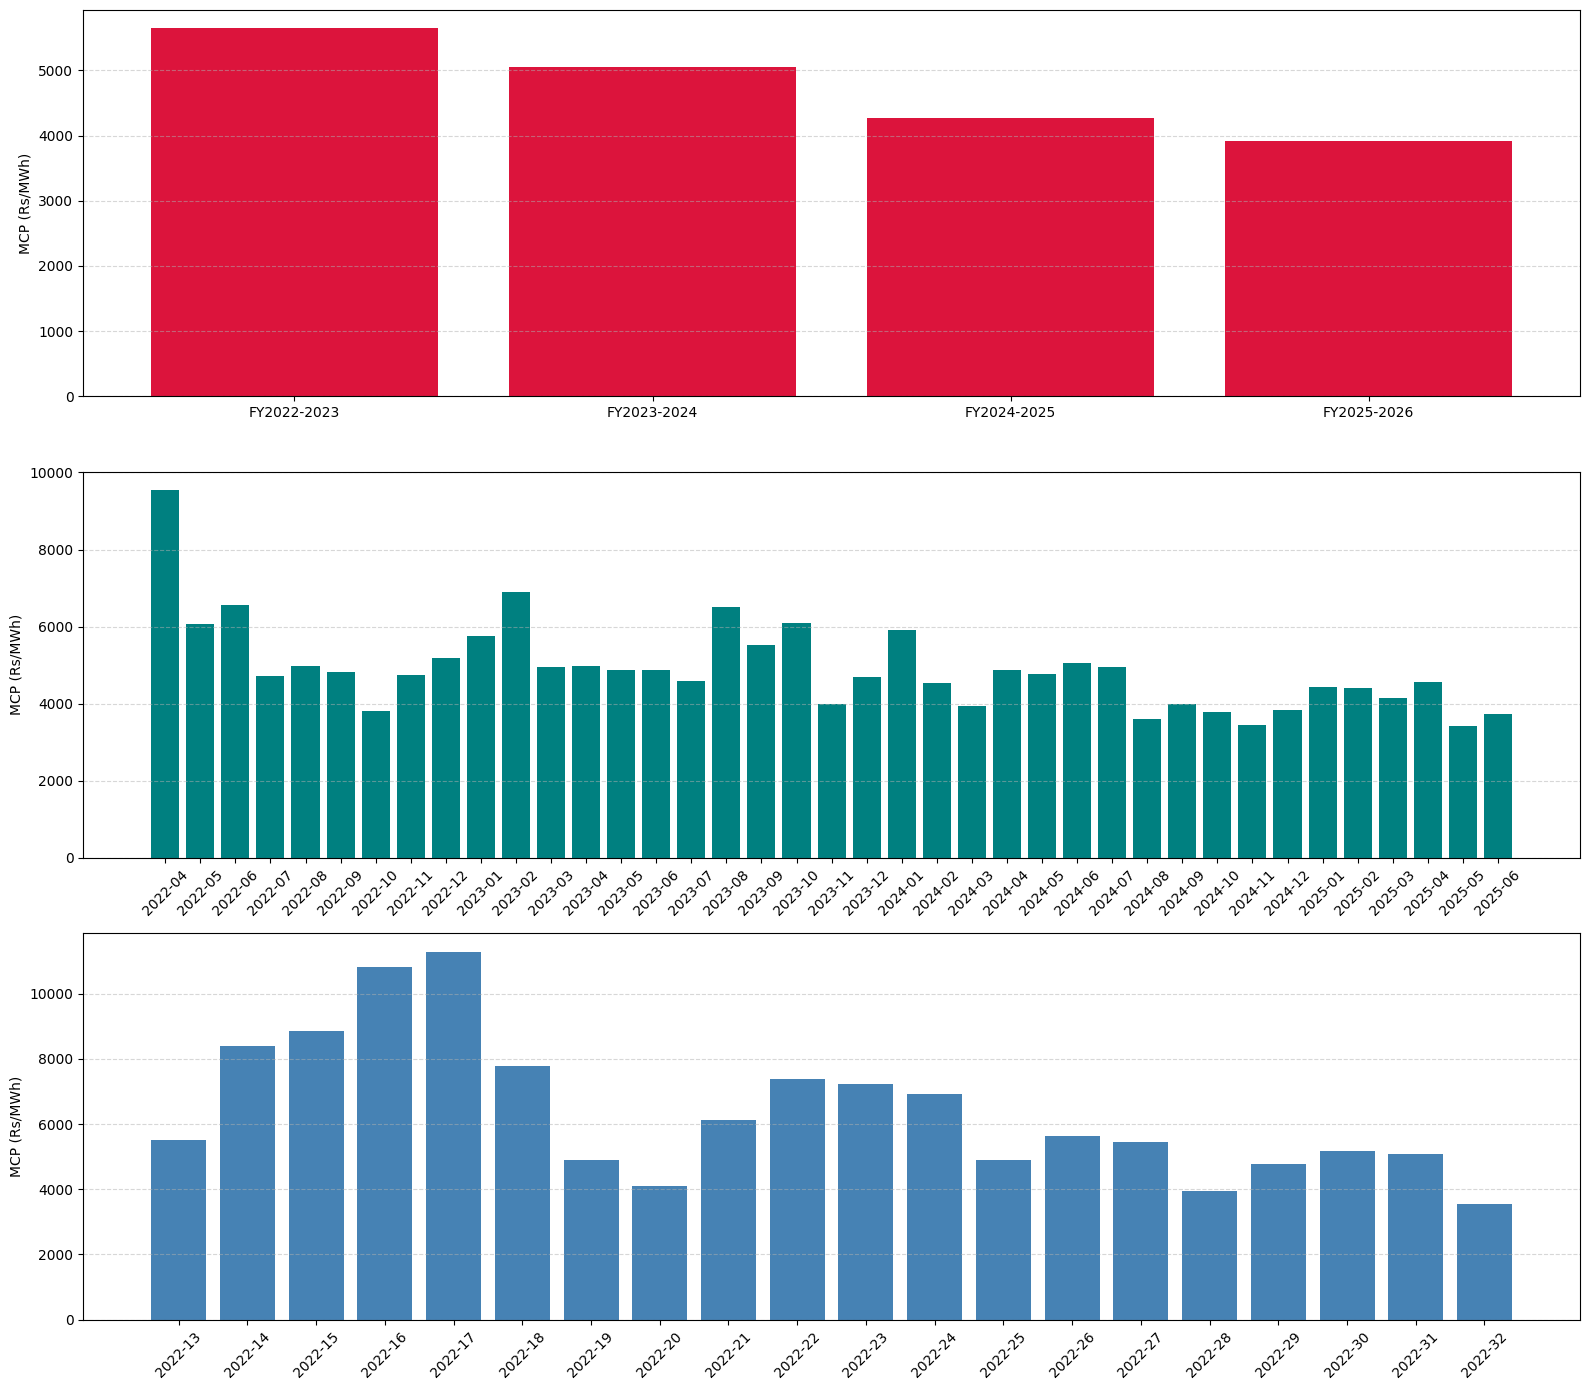

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Excel
file_path = '/content/RTM_Market Snapshot april2022-june2025.xlsx'
df = pd.read_excel(file_path)

# Clean columns
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# ---- MCP by Week ----
df['Week'] = df['Date'].dt.strftime('%Y-%U')
weekly_mcp = df.groupby('Week')['MCP (Rs/MWh) *'].mean().reset_index()

# ---- MCP by Month ----
df['Month'] = df['Date'].dt.to_period('M')
monthly_mcp = df.groupby('Month')['MCP (Rs/MWh) *'].mean().reset_index()

# ---- MCP by FY ----
def get_fy(date):
    return f"FY{date.year}-{date.year+1}" if date.month >= 4 else f"FY{date.year-1}-{date.year}"
df['FY'] = df['Date'].apply(get_fy)
fy_mcp = df.groupby('FY')['MCP (Rs/MWh) *'].mean().reset_index()

# ---- Plotting side-by-side bars ----
fig, axs = plt.subplots(3, 1, figsize=(16, 14))

# Bar Plot 1 – FY-wise MCP
axs[0].bar(fy_mcp['FY'], fy_mcp['MCP (Rs/MWh) *'], color='crimson')
axs[0].set_title('')
axs[0].set_ylabel('MCP (Rs/MWh)')
axs[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Bar Plot 2 – Monthly MCP
axs[1].bar(monthly_mcp['Month'].astype(str), monthly_mcp['MCP (Rs/MWh) *'], color='teal')
axs[1].set_title('')
axs[1].set_ylabel('MCP (Rs/MWh)')
axs[1].set_xticks(np.arange(len(monthly_mcp['Month'])))
axs[1].set_xticklabels(monthly_mcp['Month'].astype(str), rotation=45)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Bar Plot 3 – Weekly MCP (limit to first 20 for clarity)
axs[2].bar(weekly_mcp['Week'][:20], weekly_mcp['MCP (Rs/MWh) *'][:20], color='steelblue')
axs[2].set_title('')
axs[2].set_ylabel('MCP (Rs/MWh)')
axs[2].set_xticks(np.arange(20))
axs[2].set_xticklabels(weekly_mcp['Week'][:20], rotation=45)
axs[2].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


*Average MCP*
*  Yearly Trend: MCP is steadily declining from FY2022-23 to FY2025-26.
*  Monthly Trend: MCP was highest in April 2022 and shows a gradual downward trend with fluctuations.
*  Weekly Trend: MCP showed high spikes in early weeks (e.g., Week 2023-16, 2023-17), then became more stable.
*  Overall: The MCP trend is declining over time, with short-term volatility early on but stabilization in recent periods.

*Hourly Average MCP (Market Clearing Price)*
*  Lowest MCP occurs around Hour 14 (2 PM) (~₹3000/MWh).
*  Highest MCP is at Hour 20 (8 PM) (~₹7400/MWh).
*  MCP declines steadily from midnight to early afternoon.
*  Sharp increase in MCP from Hour 15 to 20.
*  Evening hours (17–21) have significantly higher MCP, likely due to peak demand.

*Month-wise Seasonal Trend of MCV (Market Clearing Volume)*
*  Peak MCV occurs in May and June (~4400 MW), indicating high market activity.
*  Secondary peak seen in September.
*  Lowest MCV is recorded in November, followed by December and January.
*  Sharp rise in MCV from March to May, and a sharp fall from September to November.
*  Suggests seasonal factors (e.g., summer demand, monsoon hydro generation) strongly influence clearing volumes.

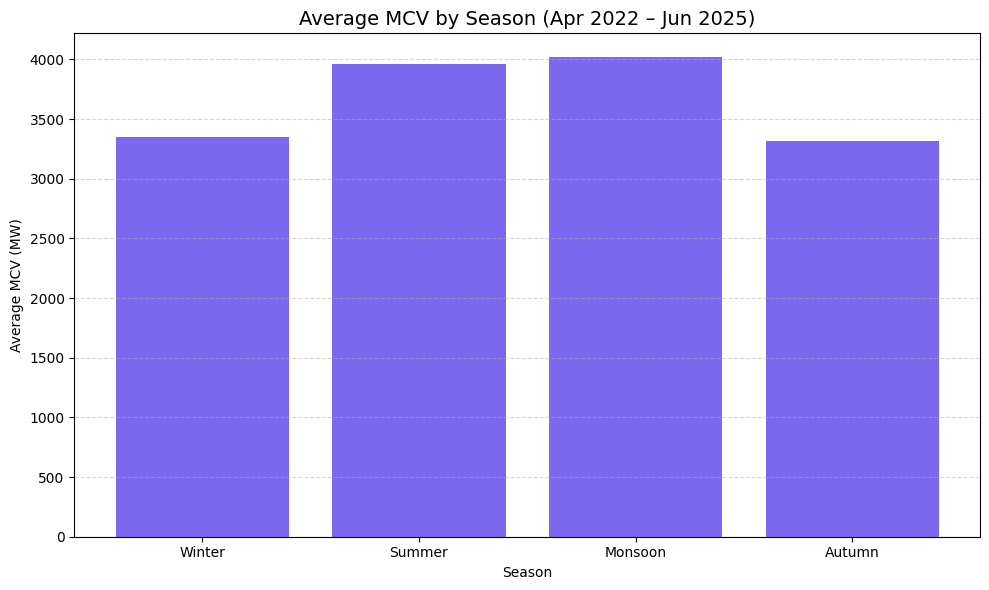

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel file
file_path = '/content/RTM_Market Snapshot april2022-june2025.xlsx'
df = pd.read_excel(file_path)

# Clean column names and parse dates
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Define season from month
def get_season(month):
    if month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['Date'].dt.month.apply(get_season)

# Group by Season and calculate average MCV
seasonal_mcv = df.groupby('Season')['MCV (MW)'].mean().reset_index()

# Sort in logical order
season_order = ['Winter', 'Summer', 'Monsoon', 'Autumn']
seasonal_mcv['Season'] = pd.Categorical(seasonal_mcv['Season'], categories=season_order, ordered=True)
seasonal_mcv = seasonal_mcv.sort_values('Season')

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(seasonal_mcv['Season'], seasonal_mcv['MCV (MW)'], color='mediumslateblue')
plt.title('Average MCV by Season (Apr 2022 – Jun 2025)', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Average MCV (MW)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


*Average MCV by Season (Apr 2022 – Jun 2025)*
*  Highest MCV is observed in the Monsoon season, slightly above Summer.
*  Summer also shows high MCV, indicating strong market clearance during peak demand months.
*  Winter and Autumn have lower MCV, suggesting reduced clearing activity.
*  Indicates seasonal impact on market participation, likely due to generation mix (e.g., hydro in monsoon) and demand fluctuations.

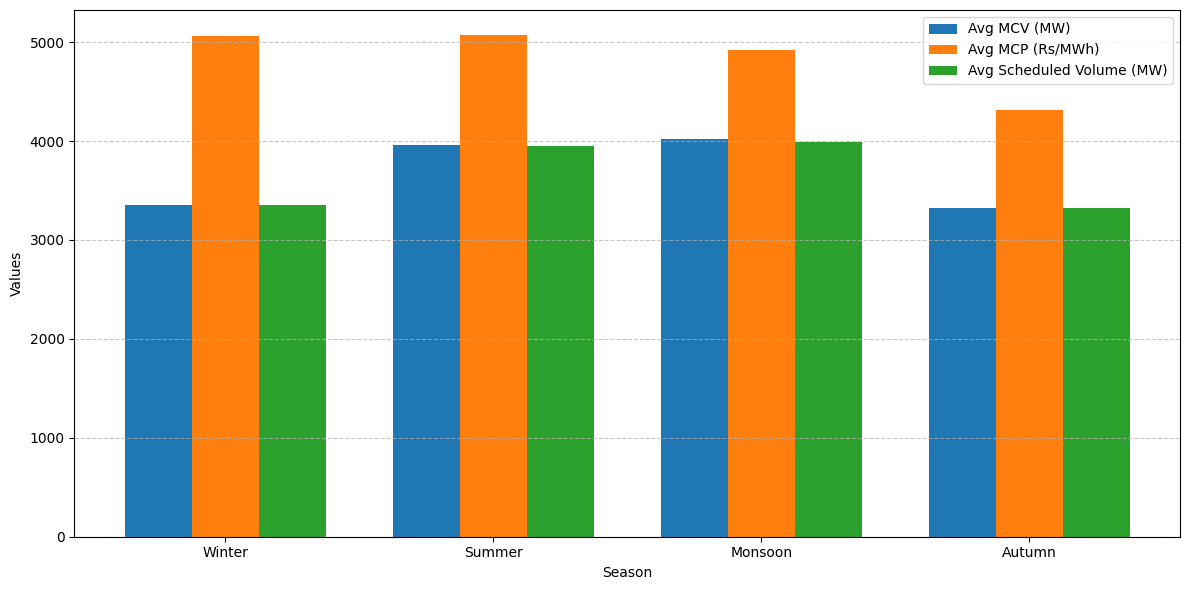

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
file_path = '/content/RTM_Market Snapshot april2022-june2025.xlsx'
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Function to categorize seasons
def get_season(date):
    month = date.month
    if month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Apply season function
df['Season'] = df['Date'].apply(get_season)

# Group by Season and calculate average
seasonal_avg = df.groupby('Season')[
    ['MCV (MW)', 'MCP (Rs/MWh) *', 'Final Scheduled Volume (MW)']
].mean().reset_index()

# Sort seasons in logical order
season_order = ['Winter', 'Summer', 'Monsoon', 'Autumn']
seasonal_avg['Season'] = pd.Categorical(seasonal_avg['Season'], categories=season_order, ordered=True)
seasonal_avg = seasonal_avg.sort_values('Season')

# ---------------- BAR PLOT ----------------
x = np.arange(len(seasonal_avg['Season']))  # the label locations
width = 0.25  # bar width

plt.figure(figsize=(12, 6))
plt.bar(x - width, seasonal_avg['MCV (MW)'], width, label='Avg MCV (MW)')
plt.bar(x, seasonal_avg['MCP (Rs/MWh) *'], width, label='Avg MCP (Rs/MWh)')
plt.bar(x + width, seasonal_avg['Final Scheduled Volume (MW)'], width, label='Avg Scheduled Volume (MW)')

# Labels and formatting
plt.xticks(x, seasonal_avg['Season'])
plt.title('')
plt.xlabel('Season')
plt.ylabel('Values')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

*Seasonal Trend of Avg MCV, MCP, and Scheduled Volume*
1.   Monsoon season shows the highest Avg MCV and Scheduled Volume, likely due to better hydro generation.
2.  Avg MCP tends to decrease as volume increases, suggesting a supply-demand effect — more available capacity leads to lower market prices.
3.  Autumn shows the lowest across all metrics, possibly indicating reduced demand or generation availability.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')